In [5]:
# Packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
#  ML Related 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import MinMaxScaler, StandardScaler # Feature Scaling
from sklearn import metrics # R^2, MSE, RMSE etc...

In [6]:
df=pd.read_csv(r"C:\Users\Hp\Downloads\Car_sales_2157_rows.csv")

In [7]:
df.head()

,Manufacturer,Model,Sales_in_thousands,four_year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919000,16.360000,Passenger,21.500000,1.8000,140.000000,101.200000,67.300000,172.400000,2.639000,13.20000,28.000000,2/2/2012,58.280150
1,Acura,TL,39.384000,19.875000,Passenger,28.400000,3.2000,225.000000,108.100000,70.300000,192.900000,3.517000,17.20000,25.000000,6/3/2011,91.370778
2,Acura,CL,14.114000,18.225000,Passenger,NaN,3.2000,225.000000,106.900000,70.600000,192.000000,3.470000,17.20000,26.000000,1/4/2012,NaN
3,Acura,RL,8.588000,29.725000,Passenger,42.000000,3.5000,210.000000,114.600000,71.400000,196.600000,3.850000,18.00000,22.000000,3/10/2011,91.389779
4,Acura,Integra,16.198997,16.466871,Passenger,19.183496,1.9694,142.631562,102.827929,68.881636,181.973358,2.689275,12.40192,26.977524,6/27/2012,58.974839


In [8]:
df["Latest_Launch"]=pd.to_datetime(df["Latest_Launch"])

In [9]:
# Number of objective columns
# Number of numerical columns
ob_col=df.dtypes[df.dtypes=="object"].index.to_list()
num_col=df.dtypes[df.dtypes!="object"].index.to_list()

In [10]:
ob_col

['Manufacturer', 'Model', 'Vehicle_type']

In [11]:
df["Manufacturer"].value_counts()

Manufacturer
Ford          151
Dodge         143
Mercedes-B    133
Chevrolet     119
Mitsubishi    111
Toyota        111
Nissan        104
Chrysler       99
Volvo          94
Pontiac        87
Oldsmobile     85
Mercury        84
Lexus          74
Volkswagen     73
Cadillac       72
Acura          67
Saturn         67
Honda          60
Buick          55
Plymouth       49
Jeep           46
Hyundai        45
Audi           42
Lincoln        39
BMW            38
Porsche        28
Saab           28
Subaru         26
Jaguar         14
Infiniti       13
Name: count, dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2157 entries, 0 to 2156
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Manufacturer            2157 non-null   object        
 1   Model                   2157 non-null   object        
 2   Sales_in_thousands      2157 non-null   float64       
 3   four_year_resale_value  2121 non-null   float64       
 4   Vehicle_type            2157 non-null   object        
 5   Price_in_thousands      2155 non-null   float64       
 6   Engine_size             2156 non-null   float64       
 7   Horsepower              2156 non-null   float64       
 8   Wheelbase               2156 non-null   float64       
 9   Width                   2156 non-null   float64       
 10  Length                  2156 non-null   float64       
 11  Curb_weight             2155 non-null   float64       
 12  Fuel_capacity           2156 non-null   float64 

In [13]:
# df.describe( percentiles=[.1,.2,.25,.5,.75, .9, .95, .96, .97, .98,.99]).T (to see outliers

In [14]:
df.groupby("Manufacturer").agg({"Sales_in_thousands": ["min", "max", "mean", "std", "count"]}) #bivarient

Sales_in_thousands                                          
                            min         max        mean         std count
Manufacturer                                                             
Acura                  8.136267   42.597461   19.802850   12.163536    67
Audi                   1.265054   21.759814   11.364016    9.226904    42
BMW                    8.434390   20.850360   14.926809    4.919182    38
Buick                 26.816753  103.455676   61.513145   27.390142    55
Cadillac               5.856943   72.517996   20.764982   20.948363    72
Chevrolet             15.878552  150.957837   54.615420   48.815364   119
Chrysler               7.267252   58.635273   30.651574   14.488626    99
Dodge                  0.835891  245.097906   79.660419   71.453270   143
Ford                  32.295119  579.652160  207.221123  148.814370   151
Honda                 11.990816  244.589684  108.485767   80.866376    60
Hyundai               27.462882   74.044096   44.539269   15.165018    45
Infiniti              21.822205   26.128718   24.015401    1.388812    13
Jaguar                14.232636   17.170824   15.634067    0.734279    14
Jeep                  51.937569  171.706672   94.746646   44.456698    46
Lexus                  3.008205   53.807621   17.450864   15.522603    74
Lincoln               12.914389   52.353439   28.723138   15.878757    39
Mercedes-B             0.884105   29.967110   11.724571   10.030181   133
Mercury               13.072929   85.000961   35.452234   23.269262    84
Mitsubishi             0.099292   60.302598   27.539302   19.682419   111
Nissan                24.665137   93.678707   56.044963   19.036504   104
Oldsmobile             1.058930   85.364219   29.398513   25.760462    85
Plymouth               1.780504   34.372179   13.709266   12.855512    49
Pontiac               17.790882  147.965927   61.025551   36.829363    87
Porsche                1.153392    9.480332    4.857609    3.763000    28
Saab                   8.193530   14.222348   11.056835    1.766359    28
Saturn                 4.965948   88.433839   33.836113   27.226583    67
Subaru                31.120282   51.031107   41.793171    7.070149    26
Toyota                 8.515247  272.540037   88.781786   71.776719   111
Volkswagen             5.427280   86.962500   33.344909   29.150588    73
Volvo                  3.160834   20.744811   12.341203    6.796304    94

In [15]:
df.groupby("Model").agg({"Sales_in_thousands": ["min", "max", "mean", "std", "count"]})

Sales_in_thousands                                        
                        min         max        mean       std count
Model                                                              
3-Sep             11.573706   14.222348   12.367938  0.700431    17
3000GT             0.099292    0.117244    0.110235  0.004731    15
300M              28.741393   34.105191   31.294495  1.371584    13
323i              18.610523   20.850360   19.802993  0.619358    13
328i               8.434390    9.642793    9.067376  0.401073    15
...                     ...         ...         ...       ...   ...
Viper              0.835891    0.949249    0.903356  0.036312    17
Voyager           23.580034   25.298759   24.424583  0.458450    11
Windstar         145.530628  170.569715  157.625648  6.348755    14
Wrangler          51.937569   61.785128   56.287584  2.676568    18
Xterra            49.585752   58.528042   54.062796  2.874259    16

[156 rows x 5 columns]

In [16]:
df.groupby("Vehicle_type").agg({"Sales_in_thousands": ["min", "max", "mean", "std", "count"]})

Sales_in_thousands                                         
                            min         max       mean         std count
Vehicle_type                                                            
Car                    7.667864  579.652160  88.560679  108.355435   550
Passenger              0.099292  272.540037  40.897461   49.476099  1607

In [17]:
num_col

['Sales_in_thousands',
 'four_year_resale_value',
 'Price_in_thousands',
 'Engine_size',
 'Horsepower',
 'Wheelbase',
 'Width',
 'Length',
 'Curb_weight',
 'Fuel_capacity',
 'Fuel_efficiency',
 'Latest_Launch',
 'Power_perf_factor']

In [18]:
df[['Sales_in_thousands','four_year_resale_value','Price_in_thousands','Engine_size','Horsepower','Wheelbase',
    'Width','Length','Curb_weight','Fuel_capacity','Fuel_efficiency','Power_perf_factor']].corr() #correlation num to num

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
Sales_in_thousands,1.000000,-0.261224,-0.279494,0.043805,-0.164475,0.355556,0.120342,0.253727,0.055817,0.127601,-0.052847,-0.199074
four_year_resale_value,-0.261224,1.000000,0.827429,0.536951,0.716769,-0.011479,0.109833,-0.004952,0.331295,0.312790,-0.374587,0.759159
Price_in_thousands,-0.279494,0.827429,1.000000,0.647465,0.826242,0.085671,0.215365,0.097075,0.501945,0.414395,-0.458474,0.887186
Engine_size,0.043805,0.536951,0.647465,1.000000,0.834948,0.361205,0.470490,0.393430,0.696528,0.619266,-0.684320,0.819818
Horsepower,-0.164475,0.716769,0.826242,0.834948,1.000000,0.223280,0.366482,0.278681,0.561862,0.471006,-0.569523,0.968681
Wheelbase,0.355556,-0.011479,0.085671,0.361205,0.223280,1.000000,0.373083,0.587162,0.505832,0.503644,-0.364708,0.205375
Width,0.120342,0.109833,0.215365,0.470490,0.366482,0.373083,1.000000,0.395178,0.473083,0.409208,-0.380586,0.341473
Length,0.253727,-0.004952,0.097075,0.393430,0.278681,0.587162,0.395178,1.000000,0.486409,0.430623,-0.307129,0.247654
Curb_weight,0.055817,0.331295,0.501945,0.696528,0.561862,0.505832,0.473083,0.486409,1.000000,0.804760,-0.741112,0.574315
Fuel_capacity,0.127601,0.312790,0.414395,0.619266,0.471006,0.503644,0.409208,0.430623,0.804760,1.000000,-0.732794,0.477512


## Preprocessing 

In [19]:
df.isnull().sum()

Manufacturer               0
Model                      0
Sales_in_thousands         0
four_year_resale_value    36
Vehicle_type               0
Price_in_thousands         2
Engine_size                1
Horsepower                 1
Wheelbase                  1
Width                      1
Length                     1
Curb_weight                2
Fuel_capacity              1
Fuel_efficiency            3
Latest_Launch              0
Power_perf_factor          2
dtype: int64

In [20]:
df1=df.dropna()  # Drop NA

In [21]:
df1.isnull().sum()

Manufacturer              0
Model                     0
Sales_in_thousands        0
four_year_resale_value    0
Vehicle_type              0
Price_in_thousands        0
Engine_size               0
Horsepower                0
Wheelbase                 0
Width                     0
Length                    0
Curb_weight               0
Fuel_capacity             0
Fuel_efficiency           0
Latest_Launch             0
Power_perf_factor         0
dtype: int64

In [22]:
df.shape

(2157, 16)

In [23]:
df1.shape

(2117, 16)

In [24]:
((2157-2117)/2157)*100

1.854427445526194

In [25]:
# Seperate Numerical and categorical data 
# we want to fill numerical data by mean and categorical data mode

In [26]:
num_data=df.select_dtypes(include=[np.number])
obj_data=df.select_dtypes(include="object")

In [27]:
obj_data.isnull().sum()

Manufacturer    0
Model           0
Vehicle_type    0
dtype: int64

In [28]:
# impute missing value in numerical by filling mean value
# num_data.fillna(value=0) # filling with 0
num_data1=num_data.fillna(num_data.mean()) # filling with 0

In [29]:
# num_data1.isnull().sum()

## outlier handling 

In [30]:
num_data1.describe(percentiles=[.1,.2,.25,.5,.75, .9, .95, .96, .97, .98,.99]).T

,count,mean,std,min,10%,20%,25%,50%,75%,90%,95%,96%,97%,98%,99%,max
Sales_in_thousands,2157.0,53.050808,72.421474,0.099292,4.954336,10.252683,13.445601,28.704315,65.391062,129.613823,214.345038,226.830526,241.176020,252.783426,289.541058,579.652160
four_year_resale_value,2157.0,17.982347,9.937337,4.757916,9.327235,11.167183,12.275000,16.790967,19.011442,27.817352,39.626266,41.351887,48.898658,56.838564,60.442015,68.698710
Price_in_thousands,2157.0,27.481806,14.606597,8.661101,13.705020,16.955621,17.916601,23.643775,32.064658,44.440848,58.140082,66.088496,71.024675,74.943461,84.896364,94.356347
Engine_size,2157.0,3.065625,1.066723,0.909975,1.918407,2.109255,2.255067,2.939620,3.615409,4.553255,4.918659,5.115725,5.277465,5.594098,5.879090,8.598311
Horsepower,2157.0,186.629011,59.077624,48.686496,119.498390,137.327003,145.344549,180.171535,215.000000,263.067964,298.559530,304.773781,313.082241,325.437267,361.805339,494.729103
Wheelbase,2157.0,107.510670,9.390922,83.580637,96.449287,100.101850,101.356575,106.985301,112.688469,118.601872,122.946795,124.354534,126.867763,130.704028,139.511371,154.636625
Width,2157.0,71.133353,4.759773,57.229280,65.131469,67.118224,67.883854,70.748328,74.230177,77.470782,79.421081,79.988945,80.779748,81.635585,83.105043,88.346521
Length,2157.0,187.298106,16.179303,136.292576,167.492448,174.642941,176.600000,186.878571,197.299408,207.677719,214.985322,216.850344,219.445424,222.964763,227.739587,246.005992
Curb_weight,2157.0,3.359723,0.613038,1.801143,2.615976,2.867167,2.947048,3.320534,3.756811,4.118790,4.367512,4.469176,4.562724,4.739112,5.381841,6.277233
Fuel_capacity,2157.0,17.927457,3.845524,9.500846,13.400408,14.958326,15.537462,17.450818,19.717300,22.972589,25.268720,25.734384,26.450099,27.913629,31.263434,35.170737


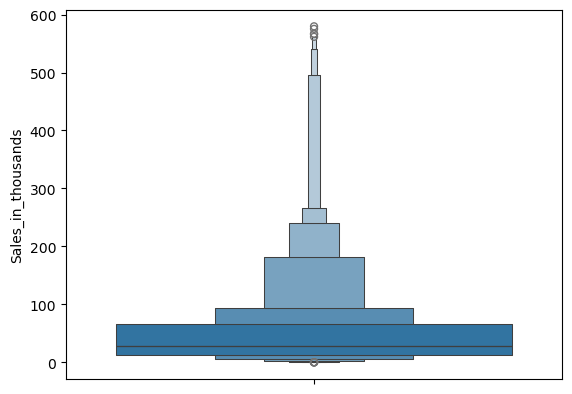

In [31]:
sns.boxenplot(data=num_data1, y="Sales_in_thousands")
plt.show()

In [32]:
def outlier_iqr_capping(x, factor=1.5):
    """ Caps the outliers based on IQR method"""
    Q1=x.quantile(0.25)
    Q3=x.quantile(0.75)
    IQR=Q3-Q1
    lower_fence=Q1-factor*IQR
    upper_fence=Q3+factor*IQR
    x=x.clip(lower_fence, upper_fence) #clip(lower, upper):If a value is less than lower_fence, it becomes lower_fence..
    #If a value is greater than upper_fence, it becomes upper_fence.....If a value is between them, it stays the same
    return x

In [33]:
# num_data2=num_data1.apply(outlier_iqr_capping) # outlier capping on all numerical columns
num_data2=num_data1.copy()

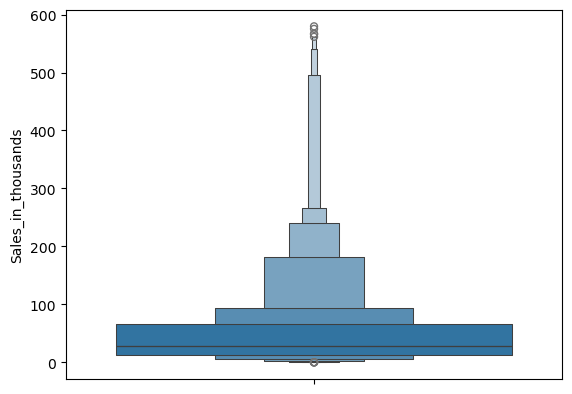

In [34]:
sns.boxenplot(data=num_data2, y="Sales_in_thousands")
plt.show()

In [35]:
num_data2.duplicated().sum() # No duplicated

np.int64(0)

### Encoding : convert non numerical to numerical

In [36]:
num_data2.columns

Index(['Sales_in_thousands', 'four_year_resale_value', 'Price_in_thousands',
       'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length',
       'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Power_perf_factor'],
      dtype='object')

In [37]:
obj_data.columns

Index(['Manufacturer', 'Model', 'Vehicle_type'], dtype='object')

In [38]:
data_after_outlier_missing=pd.concat([obj_data, num_data2, df[["Latest_Launch"]] ], axis=1) #adding date column also

In [39]:
data_after_outlier_missing.shape

(2157, 16)

In [40]:
data_with_dummy=pd.get_dummies(data=data_after_outlier_missing, columns=["Vehicle_type"], drop_first=True, dtype="int")

In [41]:
data_with_dummy.drop(columns=["Manufacturer", "Model"], inplace=True)

In [42]:
# data_with_dummy.info()

In [43]:
today=pd.Timestamp.today()
data_with_dummy["age_car"] =(today.year- data_with_dummy["Latest_Launch"].dt.year)
data_with_dummy["age_car"].value_counts()

age_car
15    844
14    838
16    255
13    190
17     17
18      9
19      4
Name: count, dtype: int64

In [44]:
data_with_dummy.drop(columns=["Latest_Launch"], inplace=True)

In [45]:
# data_with_dummy.head()

## After cleaning 

## Assumptions 

#### normality 

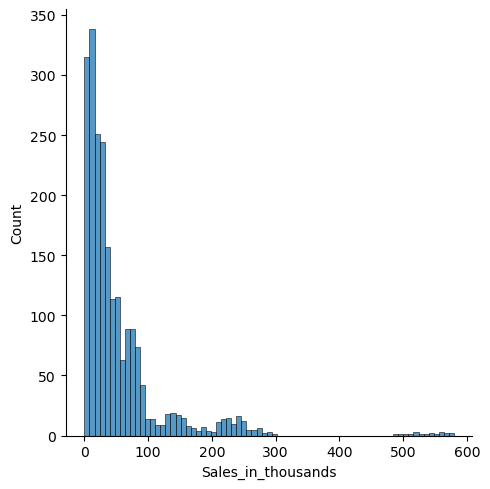

ShapiroResult(statistic=np.float64(0.6286920209287323), pvalue=np.float64(7.173127858197607e-56))


In [46]:
sns.displot(data_with_dummy["Sales_in_thousands"])
plt.show()
from scipy.stats import shapiro
# null= Normal
# Alternative - not normal
print(shapiro(data_with_dummy["Sales_in_thousands"]))

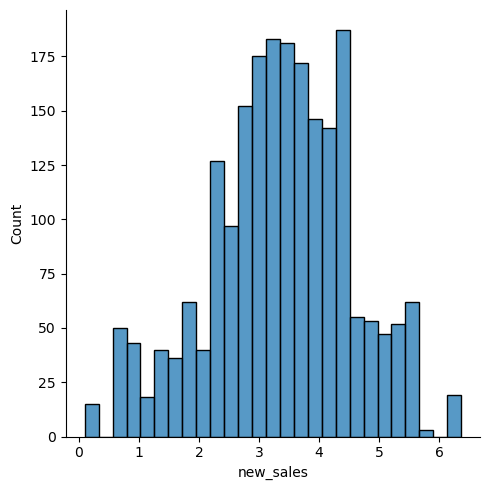

ShapiroResult(statistic=np.float64(0.9893023920051804), pvalue=np.float64(1.4094453336449522e-11))


In [47]:
data_with_dummy["new_sales"]=np.log1p(data_with_dummy["Sales_in_thousands"])
sns.displot(data_with_dummy["new_sales"])
plt.show()
from scipy.stats import shapiro
# null= Normal
# Alternative - not normal
print(shapiro(data_with_dummy["new_sales"]))

#### Linearity  : target variable must have high correlation with x features

#### Multicollinearity

In [48]:
# data_with_dummy.drop(columns=["new_sales"], inplace=True)

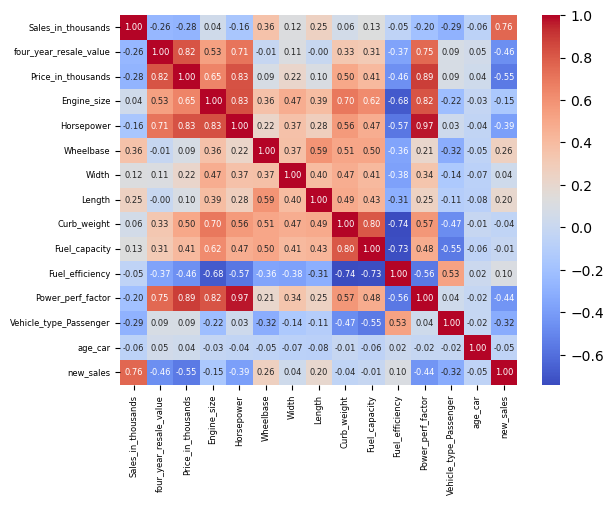

In [49]:
cr=data_with_dummy.corr()
# cr=cr.where(cr.abs()>.5)
sns.heatmap(cr, cmap="coolwarm", fmt=".2f",annot=True,annot_kws={"size" :6})
plt.xticks(rotation=90,fontsize=6)
plt.yticks(rotation=0,fontsize=6)
plt.show()

### feature selection: vif - removing features with High multicollinearity

In [50]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(X):
    a=pd.DataFrame({"feature": X.columns, 
                    "VIF" : [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
    a=a.sort_values(by=["VIF"], ascending=False)
    return a

In [51]:
x_col=['Price_in_thousands',
       'Engine_size', 
        'Fuel_efficiency', 
       'Vehicle_type_Passenger',]
calculate_vif(data_with_dummy[x_col])

,feature,VIF
1,Engine_size,13.100386
2,Fuel_efficiency,10.469809
0,Price_in_thousands,8.923409
3,Vehicle_type_Passenger,5.875043


## Model development

In [52]:
# x_col=['four_year_resale_value', 'Price_in_thousands',
#        'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length',
#        'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Power_perf_factor',
#        'Vehicle_type_Passenger', 'age_car', ]

In [53]:
x_col=['Price_in_thousands',
       'Engine_size', 
        'Fuel_efficiency', 
       'Vehicle_type_Passenger']

In [54]:
y=data_with_dummy["new_sales"]
x=data_with_dummy[x_col]

In [55]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=.3, random_state=100)

In [56]:
x_train.head()

,Price_in_thousands,Engine_size,Fuel_efficiency,Vehicle_type_Passenger
1767,31.409126,2.227947,22.130156,1
1824,15.146889,2.155916,28.572711,1
2075,24.623509,1.823619,22.881490,1
1676,23.655231,3.608713,22.662529,0
1860,19.777856,2.423556,23.884324,0


In [57]:
st=StandardScaler() # values ko same krne k liye 1 pace p lane kliye
st_fitted=st.fit(x_train) #
x_train_std=pd.DataFrame(st_fitted.transform(x_train), columns=x_train.columns)
x_test_std=pd.DataFrame(st_fitted.transform(x_test), columns=x_test.columns)

In [58]:
model0=LinearRegression()

In [59]:
model0.fit(x_train_std, y_train)

LinearRegression()

In [60]:
model0.score(x_train_std, y_train) # R^2

0.4192942660871932

In [61]:
model0.score(x_test_std, y_test) # R^2

0.44584584778834013

In [62]:
model0.coef_

array([-0.80417587,  0.38932698,  0.17014566, -0.31614648])

In [63]:
x_train.columns

Index(['Price_in_thousands', 'Engine_size', 'Fuel_efficiency',
       'Vehicle_type_Passenger'],
      dtype='object')

In [64]:
model0.intercept_

np.float64(3.3561608116443598)

### Evaluation

In [65]:
pred_train=model0.predict(x_train_std)
pred_test=model0.predict(x_test_std)

In [66]:
def model_eval_reg(act, pred):
    r2 =metrics.r2_score(act, pred)
    mse =metrics.mean_squared_error(act, pred)
    rmse=metrics.root_mean_squared_error(act, pred)
    mae=metrics.mean_absolute_error(act, pred)
    mape=metrics.mean_absolute_percentage_error(act, pred)
    print("Evaluation Scores: ")
    print(f"R^2 = {r2}\nMSE = {mse}\nRMSE = {rmse}\nMAE = {mae}\nMAPE = {mape})")

In [67]:
model_eval_reg(y_train, pred_train)

Evaluation Scores: 
R^2 = 0.4192942660871932
MSE = 0.8070764778579196
RMSE = 0.89837435284959
MAE = 0.6806482244528638
MAPE = 0.4528117977177696)


In [68]:
model_eval_reg(y_test, pred_test)

Evaluation Scores: 
R^2 = 0.44584584778834013
MSE = 0.7984582688878926
RMSE = 0.8935649214734722
MAE = 0.6802434026269123
MAPE = 0.5132503185428788)


In [69]:
x_train.columns

Index(['Price_in_thousands', 'Engine_size', 'Fuel_efficiency',
       'Vehicle_type_Passenger'],
      dtype='object')

In [70]:
x_train.head()

,Price_in_thousands,Engine_size,Fuel_efficiency,Vehicle_type_Passenger
1767,31.409126,2.227947,22.130156,1
1824,15.146889,2.155916,28.572711,1
2075,24.623509,1.823619,22.881490,1
1676,23.655231,3.608713,22.662529,0
1860,19.777856,2.423556,23.884324,0


In [71]:
new_df=pd.DataFrame({"Price_in_thousands":[100],
                    "Engine_size":[5.4], "Fuel_efficiency":[22],"Vehicle_type_Passenger":[0]
                    })

In [72]:
# new_df=pd.DataFrame({"four_year_resale_value":[67],"Price_in_thousands":[100],
#                     "Engine_size":[5.4],"Horsepower":[200],"Wheelbase":[150],"Width":[80],
#                      "Length":[180],
#                      "Curb_weight":[1.5],"Fuel_capacity":[25], "Fuel_efficiency":[22],
#                      "Power_perf_factor":[70],"Vehicle_type_Passenger":[0],"age_car":[7]
#                     })

In [73]:
new_df=pd.DataFrame(st_fitted.transform(new_df), columns=new_df.columns)

In [74]:
np.expm1(model0.predict(new_df)) 

array([1.0255739])

In [75]:
pd.DataFrame({"Col": x_train.columns, "coe": model0.coef_}).sort_values(by=["coe"])

,Col,coe
0,Price_in_thousands,-0.804176
3,Vehicle_type_Passenger,-0.316146
2,Fuel_efficiency,0.170146
1,Engine_size,0.389327


In [76]:
a=pd.DataFrame({"act":y_test, "pred":pred_test})

<Axes: xlabel='act', ylabel='pred'>

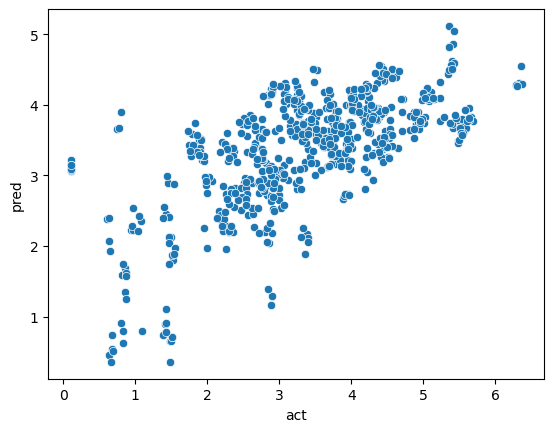

In [77]:
sns.scatterplot(data=a, x="act", y="pred")

In [78]:
# Normalize
# Outlier
# Feature Scaling 
# Multicollinearity
# VIF - Feature Selection

In [79]:
import joblib

In [80]:
joblib.dump(model0, "LinearReg.joblib")

['LinearReg.joblib']